# 05a — Sampling: NUTS without Hessian initialization (ANALYSIS)

Loads artifacts produced by `05a_sampling_no_hessian_data.ipynb` and the
Hessian saved by `04_training.ipynb`. No sampling here — only diagnostics,
figures, verdict.

**Inputs**:
- `data/hessian.pt`
- `data/results_no_hessian/{RUN_NAME}/nuts_samples_no_hessian.pt`
- `data/results_no_hessian/{RUN_NAME}/iterative/round_NN.pt` (H1-1, optional)

**Outputs** (into `data/results_no_hessian/{RUN_NAME}/`):
- `results.json` — H1 verdict + numerical summary
- `spectral_diagnostics.{pdf,png}`, `acf_heatmap.{pdf,png}`, `ess_per_direction.{pdf,png}`
- `iterative/convergence_summary.{pdf,png}`, `iterative/round_summary.json`


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Resolve project root
cwd = Path.cwd().resolve()
project_root = next(
    (
        p
        for p in (cwd, *cwd.parents)
        if (p / "packages" / "pytorch_models" / "markov_transformer.py").exists()
    ),
    None,
)
if project_root is None:
    alt_root = cwd / "projects" / "markov-chain-learning"
    if (alt_root / "packages" / "pytorch_models" / "markov_transformer.py").exists():
        project_root = alt_root
if project_root is None:
    raise RuntimeError("Could not locate markov-chain-learning project root")

DATA_DIR = project_root / "experiments" / "single-chain" / "data"
print(f"Data dir: {DATA_DIR}")


Data dir: /Users/ashrafahmed/code/slt-deep/projects/markov-chain-learning/experiments/single-chain/data


In [3]:
# ── Papermill parameters ──
RUN_NAME: str = "default"


## Load artifacts


In [ ]:
RESULTS_DIR = DATA_DIR / "results_no_hessian" / RUN_NAME
ITER_DIR = RESULTS_DIR / "iterative"

# H1 production samples
payload = torch.load(RESULTS_DIR / "nuts_samples_no_hessian.pt", weights_only=False)
config = payload["config"]
N_WARMUP = config["n_warmup"]
N_SAMPLES = config["n_samples"]
SIGMA_PRIOR = config["sigma_prior"]
DGP_REGIME = config["dgp_regime"]
MAX_TREE_DEPTH = config["max_tree_depth"]

mle_param = payload["mle_param"]
adapted_M = payload["adapted_M"]
adapted_step_size = payload["adapted_step_size"]

samples = payload["chains"][0]["parameters"].float()
chain0_diag = payload["chains"][0]["diagnostics"]

print(f"Run: {RUN_NAME}")
print(f"  samples: {tuple(samples.shape)}  (N, d)")
print(f"  warmup: {N_WARMUP}, production: {N_SAMPLES}")
print(f"  accept: {payload['chains'][0]['acceptance_rate']:.3f}")
print(f"  step size: {adapted_step_size:.4e}")


Run: default
  samples: (50, 910)  (N, d)
  warmup: 150, production: 50
  accept: 1.000
  step size: 1.0962e-03


In [5]:
# Hessian (computed once in 04_training.ipynb)
hess = torch.load(DATA_DIR / "hessian.pt", weights_only=True)
H_mle = hess["H_mle"].float()
d = int(H_mle.shape[0])
assert d == samples.shape[1], f"Dimension mismatch: H {d} vs samples {samples.shape[1]}"

eigvals, eigvecs = torch.linalg.eigh(H_mle)
# Threshold for non-degenerate directions (consistent with training nb)
eigval_threshold = eigvals.abs().max().item() * 1e-3
n_nd = int((eigvals.abs() > eigval_threshold).sum())
n_degen = d - n_nd

print(f"Hessian: λ ∈ [{eigvals[0]:.4e}, {eigvals[-1]:.4e}]")
print(f"  {n_nd} non-degenerate, {n_degen} degenerate directions")


Hessian: λ ∈ [-7.3382e-02, 3.9659e+00]
  158 non-degenerate, 752 degenerate directions


## Spectral diagnostics: eig(H), eig(M⁻¹), eig(H₊·M)


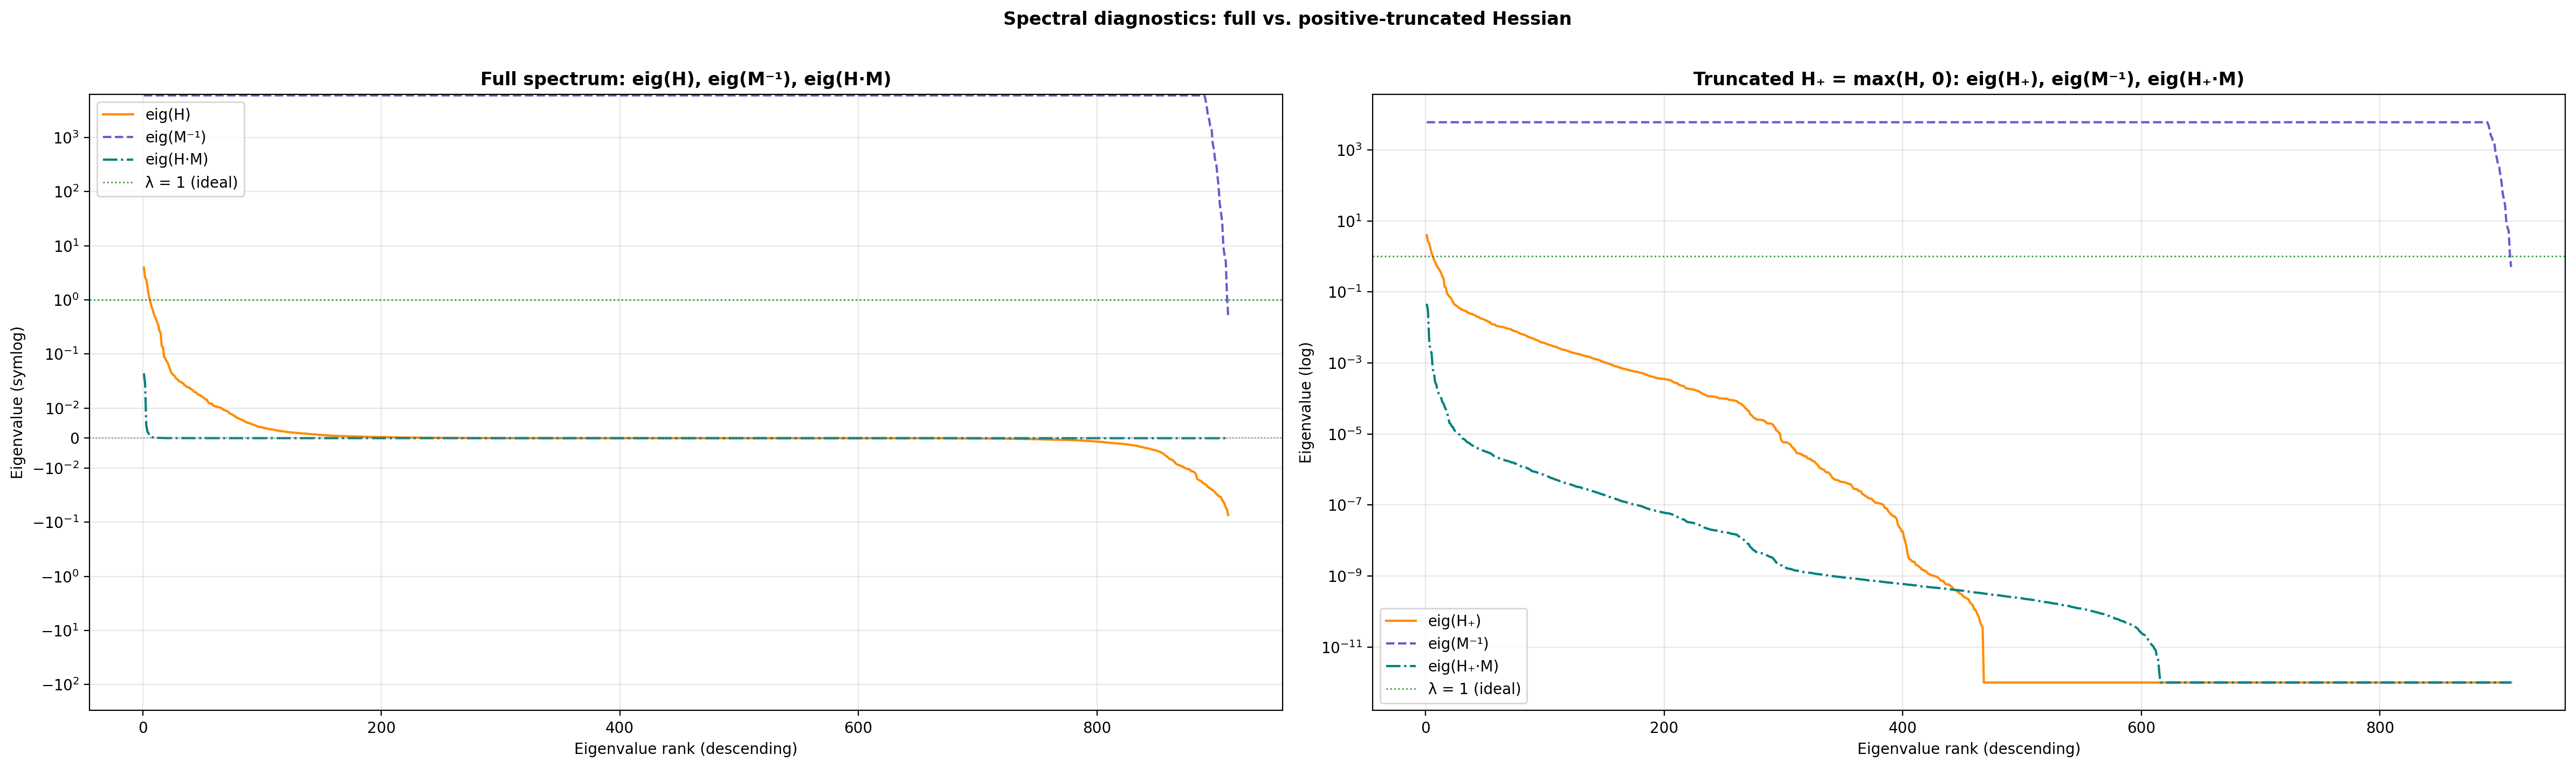


H₊ has 467 positive modes
eig(H₊·M) within [0.5, 1.5]: 0/910


In [ ]:
# eig(M) and eig(M^-1)
M_cpu = adapted_M.detach().cpu().float()
eigvals_M = torch.linalg.eigvalsh(M_cpu)
eig_Minv = 1.0 / eigvals_M.clamp(min=1e-10)
eig_Minv_sorted = torch.sort(eig_Minv, descending=True).values

# Full signed Hessian spectrum
eig_h_sorted = torch.sort(eigvals, descending=True).values

# eig(H · M) via similarity transform with M^{1/2}
eigvals_m_loc, eigvecs_m_loc = torch.linalg.eigh(M_cpu)
M_sqrt = (
    eigvecs_m_loc @ torch.diag(eigvals_m_loc.clamp(min=1e-10).sqrt()) @ eigvecs_m_loc.T
)
HM_sym = M_sqrt @ H_mle @ M_sqrt
eig_HM_sorted = torch.sort(torch.linalg.eigvalsh(HM_sym), descending=True).values

# Truncated H₊ = clamp(H, 0)
eigvals_h_trunc = eigvals.clamp(min=0)
H_trunc = eigvecs @ torch.diag(eigvals_h_trunc) @ eigvecs.T
eig_Htrunc_sorted = torch.sort(eigvals_h_trunc, descending=True).values

HtruncM_sym = M_sqrt @ H_trunc @ M_sqrt
eig_HtruncM_sorted = torch.sort(
    torch.linalg.eigvalsh(HtruncM_sym), descending=True
).values
rank_idx = torch.arange(1, d + 1)

# ── Plot ──
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(24, 7), sharex=True)

ax_l.plot(
    rank_idx.numpy(), eig_h_sorted.numpy(), color="darkorange", lw=1.5, label="eig(H)"
)
ax_l.plot(
    rank_idx.numpy(),
    eig_Minv_sorted.numpy(),
    color="slateblue",
    lw=1.5,
    ls="--",
    label="eig(M⁻¹)",
)
ax_l.plot(
    rank_idx.numpy(),
    eig_HM_sorted.numpy(),
    color="teal",
    lw=1.5,
    ls="-.",
    label="eig(H·M)",
)
ax_l.axhline(1, color="green", lw=1.0, ls=":", alpha=0.8, label="λ = 1 (ideal)")
ax_l.axhline(0, color="gray", lw=0.8, ls=":")
ax_l.set_yscale("symlog", linthresh=1e-2, linscale=0.5)
ax_l.set_xlabel("Eigenvalue rank (descending)")
ax_l.set_ylabel("Eigenvalue (symlog)")
ax_l.set_title("Full spectrum: eig(H), eig(M⁻¹), eig(H·M)", fontweight="bold")
ax_l.grid(True, alpha=0.3)
ax_l.legend()

ax_r.plot(
    rank_idx.numpy(),
    eig_Htrunc_sorted.clamp(min=1e-12).numpy(),
    color="darkorange",
    lw=1.5,
    label="eig(H₊)",
)
ax_r.plot(
    rank_idx.numpy(),
    eig_Minv_sorted.numpy(),
    color="slateblue",
    lw=1.5,
    ls="--",
    label="eig(M⁻¹)",
)
ax_r.plot(
    rank_idx.numpy(),
    eig_HtruncM_sorted.clamp(min=1e-12).numpy(),
    color="teal",
    lw=1.5,
    ls="-.",
    label="eig(H₊·M)",
)
ax_r.axhline(1, color="green", lw=1.0, ls=":", alpha=0.8, label="λ = 1 (ideal)")
ax_r.set_yscale("log")
ax_r.set_xlabel("Eigenvalue rank (descending)")
ax_r.set_ylabel("Eigenvalue (log)")
ax_r.set_title(
    "Truncated H₊ = max(H, 0): eig(H₊), eig(M⁻¹), eig(H₊·M)", fontweight="bold"
)
ax_r.grid(True, alpha=0.3)
ax_r.legend()

fig.suptitle(
    "Spectral diagnostics: full vs. positive-truncated Hessian",
    fontweight="bold",
    y=1.01,
)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "spectral_diagnostics.pdf", bbox_inches="tight", dpi=150)
fig.savefig(RESULTS_DIR / "spectral_diagnostics.png", bbox_inches="tight", dpi=150)
plt.show()

n_Ht_pos = int((eig_Htrunc_sorted > 1e-12).sum())
n_HtM_near1 = int(((eig_HtruncM_sorted - 1).abs() < 0.5).sum())
print(f"\nH₊ has {n_Ht_pos} positive modes")
print(f"eig(H₊·M) within [0.5, 1.5]: {n_HtM_near1}/{d}")


## ACF in Hessian eigenbasis

Project samples into Hessian eigendirections and compute ACF per direction.


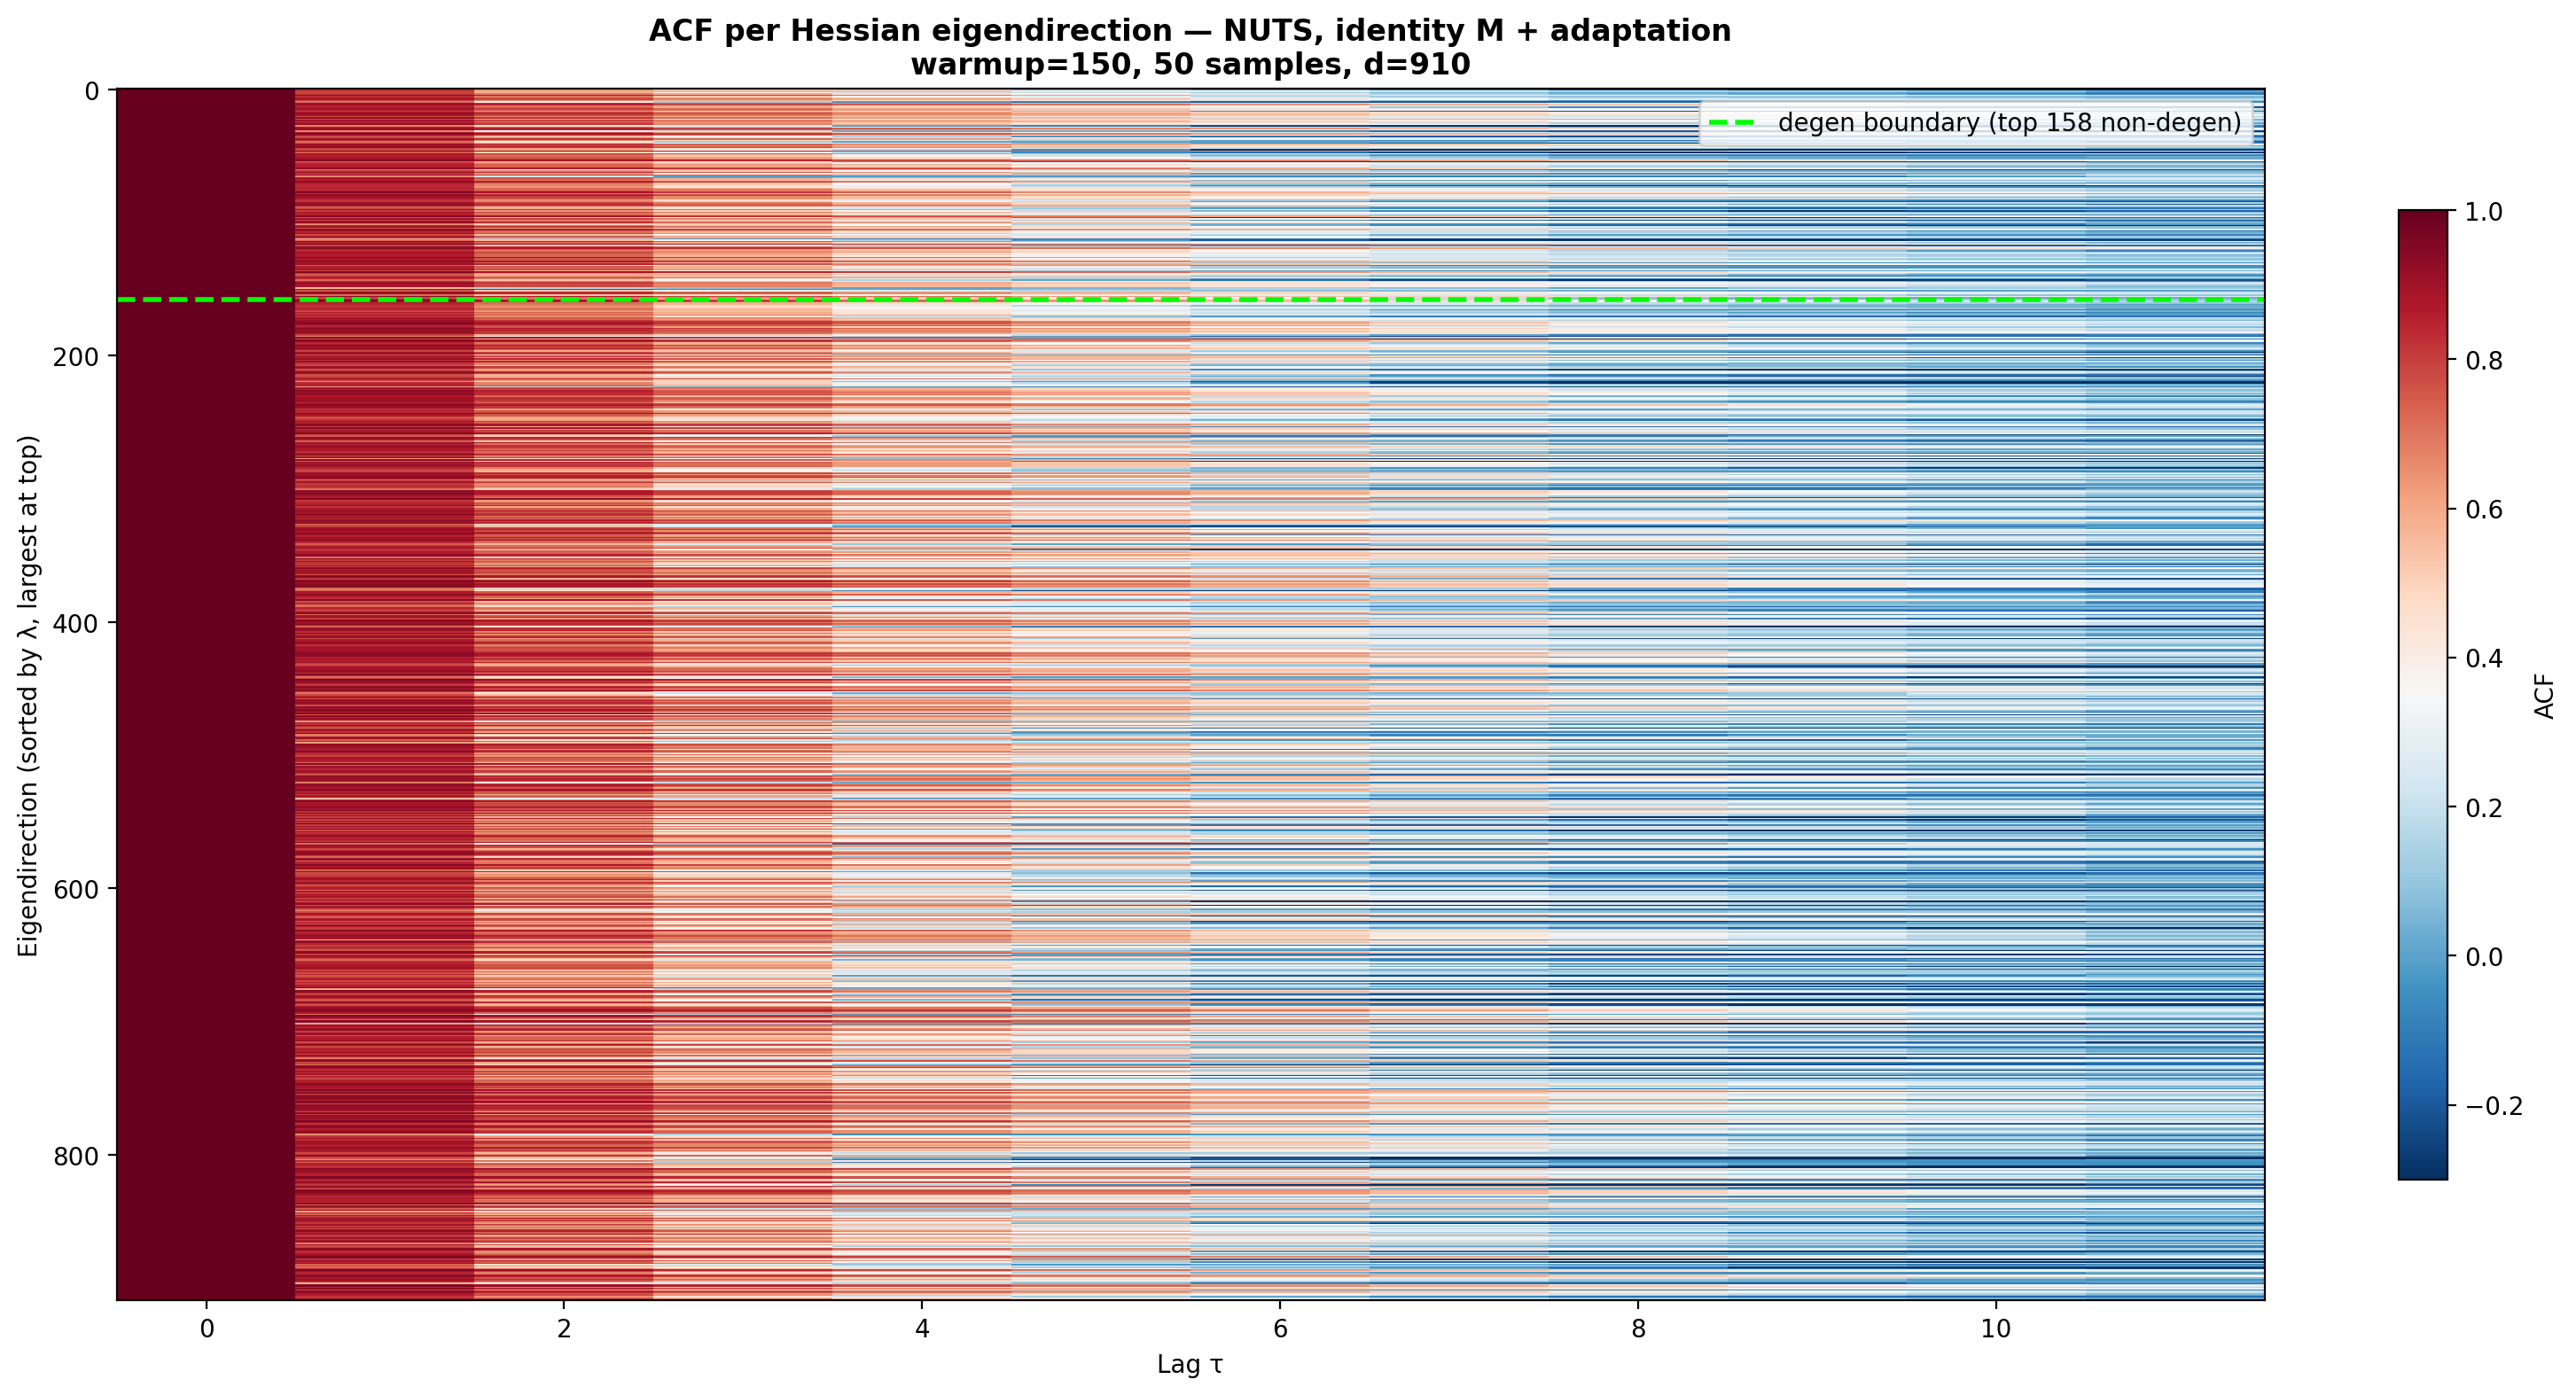

ACF@10:  median=0.125
ACF@50:  median=0.085  (nd=0.079, dg=0.088)
ACF@200: median=0.085


In [ ]:
# ── ACF per Hessian eigendirection ──
V = eigvecs.cpu().float()
MAX_LAG = min(6000, N_SAMPLES // 4)


def compute_acf_eigenbasis(samples_tensor, V, max_lag):
    """Project samples into eigenbasis, compute ACF per direction via FFT."""
    z = samples_tensor @ V
    d = z.shape[1]
    acf = torch.zeros(d, max_lag)
    for j in range(d):
        x = z[:, j]
        x = x - x.mean()
        var = x.var()
        if var < 1e-20:
            continue
        n = x.shape[0]
        padded = torch.zeros(2 * n)
        padded[:n] = x
        ft = torch.fft.rfft(padded)
        acov = torch.fft.irfft(ft * ft.conj())[:n] / n
        acf[j, :max_lag] = acov[:max_lag] / acov[0].clamp(min=1e-20)
    return acf


sort_idx = torch.argsort(eigvals, descending=True)
acf_sorted = compute_acf_eigenbasis(samples, V, MAX_LAG)[sort_idx]

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(
    acf_sorted.numpy(),
    aspect="auto",
    cmap="RdBu_r",
    vmin=-0.3,
    vmax=1.0,
    interpolation="nearest",
    origin="upper",
)
ax.set_xlabel("Lag τ")
ax.set_ylabel("Eigendirection (sorted by λ, largest at top)")
ax.set_title(
    f"ACF per Hessian eigendirection — NUTS, identity M + adaptation\n"
    f"warmup={N_WARMUP}, {N_SAMPLES} samples, d={d}",
    fontweight="bold",
)
if 0 < n_nd < d:
    ax.axhline(
        n_nd - 0.5,
        color="lime",
        lw=2,
        ls="--",
        label=f"degen boundary (top {n_nd} non-degen)",
    )
    ax.legend(loc="upper right")
plt.colorbar(im, ax=ax, shrink=0.8, label="ACF")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "acf_heatmap.pdf", bbox_inches="tight", dpi=150)
fig.savefig(RESULTS_DIR / "acf_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

acf_at_10 = acf_sorted[:, min(10, MAX_LAG - 1)]
acf_at_50 = acf_sorted[:, min(50, MAX_LAG - 1)]
acf_at_200 = acf_sorted[:, min(200, MAX_LAG - 1)]
acf50_nd = acf_sorted[:n_nd, min(50, MAX_LAG - 1)]
acf50_dg = acf_sorted[n_nd:, min(50, MAX_LAG - 1)]

print(f"ACF@10:  median={acf_at_10.median():.3f}")
print(
    f"ACF@50:  median={acf_at_50.median():.3f}  (nd={acf50_nd.median():.3f}, dg={acf50_dg.median():.3f})"
)
print(f"ACF@200: median={acf_at_200.median():.3f}")


## ESS per eigendirection


ESS all (N=50):
  min=3.1  median=5.2  max=20.6
ESS non-degenerate (158): median=5.2
ESS degenerate     (752): median=5.1


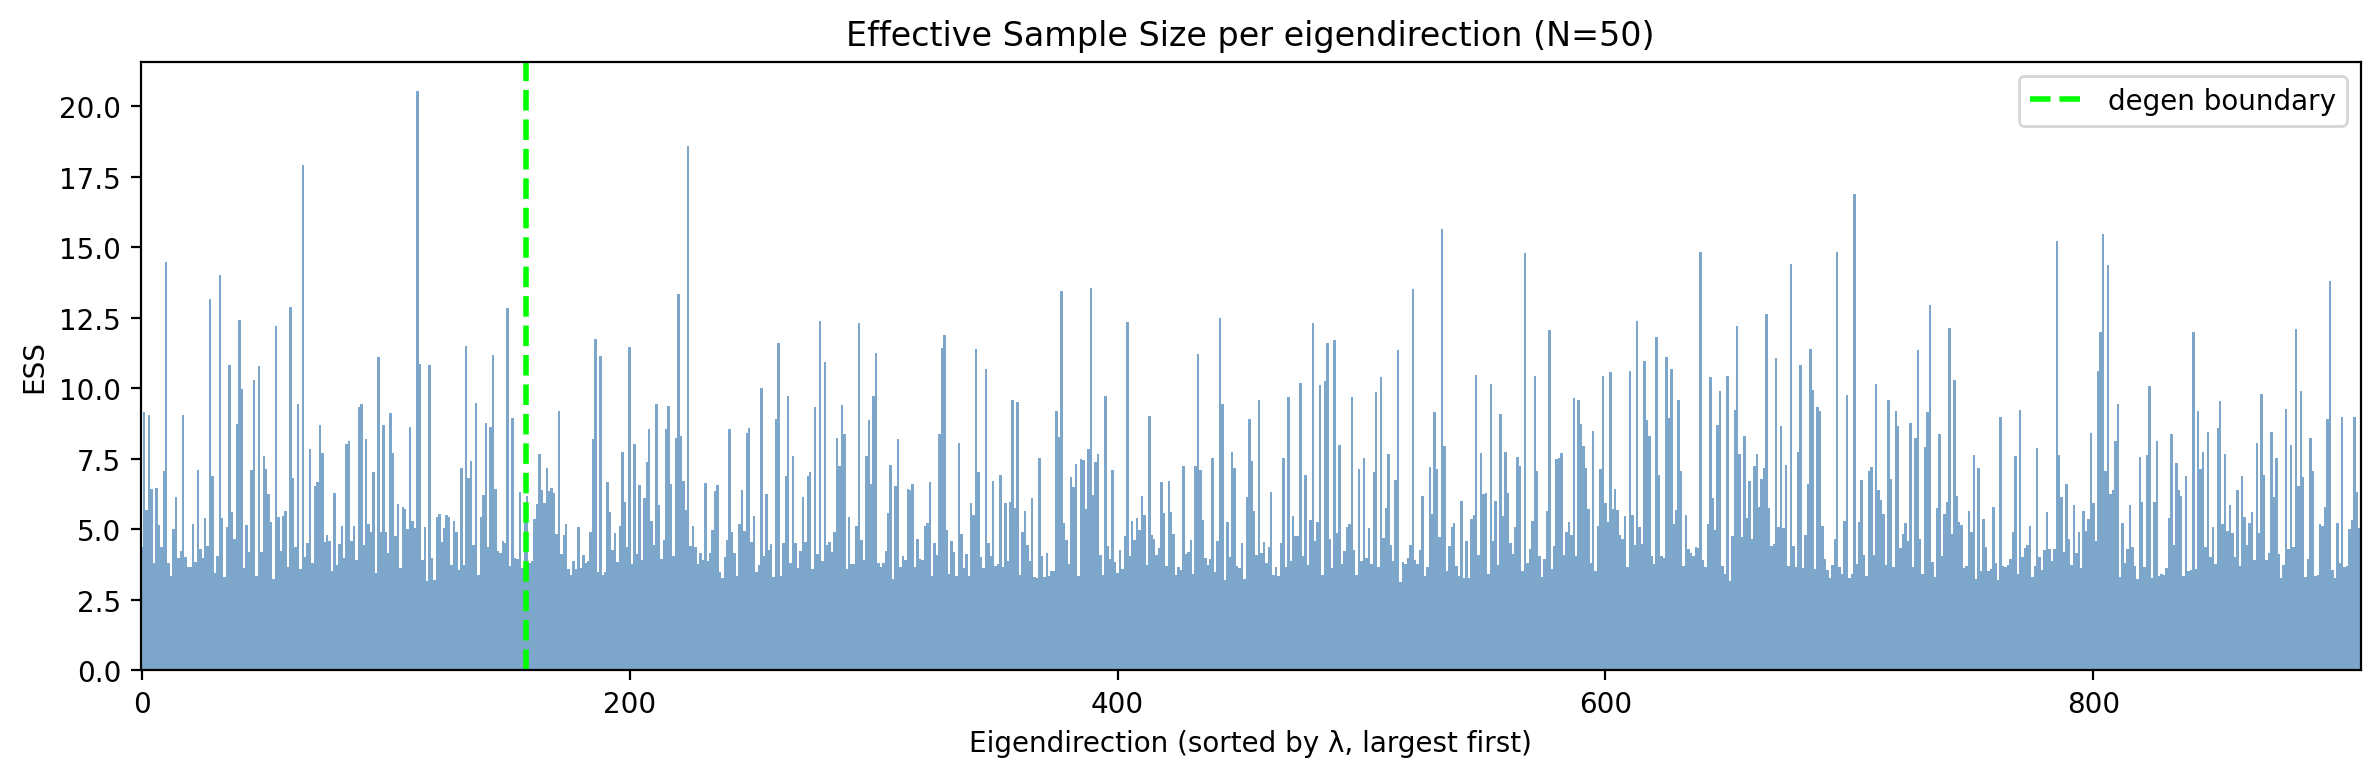

In [ ]:
def compute_ess(acf_row):
    """Initial positive sequence estimator (Geyer)."""
    total = 0.0
    for k in range(acf_row.shape[0]):
        if acf_row[k] < 0:
            break
        total += float(acf_row[k])
    tau = 1 + 2 * (total - 1)
    return N_SAMPLES / max(tau, 1.0)


ess_per_dir = torch.tensor(
    [compute_ess(acf_sorted[i]) for i in range(acf_sorted.shape[0])]
)
ess_nd = ess_per_dir[:n_nd]
ess_dg = ess_per_dir[n_nd:]

print(f"ESS all (N={N_SAMPLES}):")
print(
    f"  min={ess_per_dir.min():.1f}  median={ess_per_dir.median():.1f}  max={ess_per_dir.max():.1f}"
)
print(f"ESS non-degenerate ({n_nd}): median={ess_nd.median():.1f}")
print(f"ESS degenerate     ({n_degen}): median={ess_dg.median():.1f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(
    range(len(ess_per_dir)),
    ess_per_dir.numpy(),
    width=1.0,
    color="steelblue",
    alpha=0.7,
)
if 0 < n_nd < len(ess_per_dir):
    ax.axvline(n_nd - 0.5, color="lime", lw=2, ls="--", label="degen boundary")
    ax.legend()
ax.set_xlabel("Eigendirection (sorted by λ, largest first)")
ax.set_ylabel("ESS")
ax.set_title(f"Effective Sample Size per eigendirection (N={N_SAMPLES})")
ax.set_xlim(-0.5, len(ess_per_dir) - 0.5)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "ess_per_direction.pdf", bbox_inches="tight", dpi=150)
fig.savefig(RESULTS_DIR / "ess_per_direction.png", bbox_inches="tight", dpi=150)
plt.show()


## Verdict

- **ACF@50 median < 0.3** → hypothesis falsified (good mixing)
- **ACF@50 median > 0.5** → hypothesis confirmed (singular geometry defeats fixed M)


In [9]:
import json as _json

acf50_median = float(acf_at_50.median())
ess_median = float(ess_per_dir.median())

if acf50_median < 0.3:
    verdict = "FALSIFIED"
elif acf50_median > 0.5:
    verdict = "CONFIRMED"
else:
    verdict = "INCONCLUSIVE"

results = {
    "experiment": "05a_sampling_no_hessian",
    "run_name": RUN_NAME,
    "hypothesis": "H1: singular geometry defeats any fixed mass matrix",
    "verdict": verdict,
    "config": {
        "d": d,
        "n_warmup": N_WARMUP,
        "n_samples": N_SAMPLES,
        "max_tree_depth": MAX_TREE_DEPTH,
        "sigma_prior": SIGMA_PRIOR,
        "dgp_regime": DGP_REGIME,
    },
    "spectral": {
        "eig_H_range": [float(eig_h_sorted[-1]), float(eig_h_sorted[0])],
        "eig_Minv_range": [float(eig_Minv_sorted[-1]), float(eig_Minv_sorted[0])],
        "eig_HM_range": [float(eig_HM_sorted[-1]), float(eig_HM_sorted[0])],
        "n_hessian_positive": int((eig_h_sorted > 0).sum()),
        "n_hessian_negative": int((eig_h_sorted < 0).sum()),
        "n_Htrunc_positive": n_Ht_pos,
        "n_HtruncM_near_one": n_HtM_near1,
    },
    "acf": {
        "lag_10_median": float(acf_at_10.median()),
        "lag_50_median": acf50_median,
        "lag_200_median": float(acf_at_200.median()),
        "lag_50_nondegen_median": float(acf50_nd.median()),
        "lag_50_degen_median": float(acf50_dg.median()),
    },
    "ess": {
        "all_min": float(ess_per_dir.min()),
        "all_median": ess_median,
        "all_max": float(ess_per_dir.max()),
        "nondegen_median": float(ess_nd.median()),
        "degen_median": float(ess_dg.median()),
    },
}

with open(RESULTS_DIR / "results.json", "w") as f:
    _json.dump(results, f, indent=2)

print(f"★ H1 VERDICT: {verdict}")
print(f"  ACF@50 median = {acf50_median:.3f}")
print(f"  ESS median = {ess_median:.1f} / {N_SAMPLES}")
print(f"  Results saved to {RESULTS_DIR / 'results.json'}")


★ H1 VERDICT: FALSIFIED
  ACF@50 median = 0.085
  ESS median = 5.2 / 50
  Results saved to /Users/ashrafahmed/code/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/results_no_hessian/default/results.json


## H1-1: Iterative adaptation convergence

Load per-round checkpoints from `iterative/round_NN.pt`, recompute ACF/ESS
per round in the same Hessian eigenbasis, plot convergence.


In [ ]:
iter_results = []
round_paths = sorted(ITER_DIR.glob("round_*.pt")) if ITER_DIR.exists() else []

if round_paths:
    print(f"Found {len(round_paths)} round checkpoints")
    MAX_LAG_ITER = None

    for rp in round_paths:
        rd = torch.load(rp, weights_only=False)
        samps_r = rd["samples"].float()
        N_r = samps_r.shape[0]
        if MAX_LAG_ITER is None:
            MAX_LAG_ITER = min(500, N_r // 4)

        acf_r = compute_acf_eigenbasis(samps_r, V, MAX_LAG_ITER)[sort_idx]
        acf50_r = acf_r[:, min(50, MAX_LAG_ITER - 1)]

        def _ess(row, N):
            tot = 0.0
            for k in range(row.shape[0]):
                if row[k] < 0:
                    break
                tot += float(row[k])
            tau = 1 + 2 * (tot - 1)
            return N / max(tau, 1.0)

        ess_r = torch.tensor([_ess(acf_r[i], N_r) for i in range(acf_r.shape[0])])

        # Spectral: eig(H₊·M_r)
        M_r_cpu = rd["mass_matrix"].detach().cpu().float()
        eigvals_mr, eigvecs_mr = torch.linalg.eigh(M_r_cpu)
        M_sqrt_r = (
            eigvecs_mr @ torch.diag(eigvals_mr.clamp(min=1e-10).sqrt()) @ eigvecs_mr.T
        )
        HtM_r = M_sqrt_r @ H_trunc @ M_sqrt_r
        eig_HtM_r = torch.sort(torch.linalg.eigvalsh(HtM_r), descending=True).values

        d_info = rd["diagnostics"]
        iter_results.append(
            {
                "round": rd["round"],
                "step_size": d_info["step_size"],
                "cond_M": d_info["cond_M"],
                "acceptance_rate": d_info["acceptance_rate"],
                "n_divergences": d_info["n_divergences"],
                "mean_tree_depth": d_info["mean_tree_depth"],
                "acf50_median": float(acf50_r.median()),
                "acf50_nd_median": float(acf50_r[:n_nd].median()),
                "acf50_dg_median": float(acf50_r[n_nd:].median()),
                "ess_median": float(ess_r.median()),
                "ess_nd_median": float(ess_r[:n_nd].median()),
                "ess_dg_median": float(ess_r[n_nd:].median()),
                "n_HtM_near1": int(((eig_HtM_r - 1).abs() < 0.5).sum()),
            }
        )

    print(f"Processed {len(iter_results)} rounds")
else:
    print("No H1-1 rounds found — skipping iterative analysis.")


Found 5 round checkpoints
Processed 5 rounds


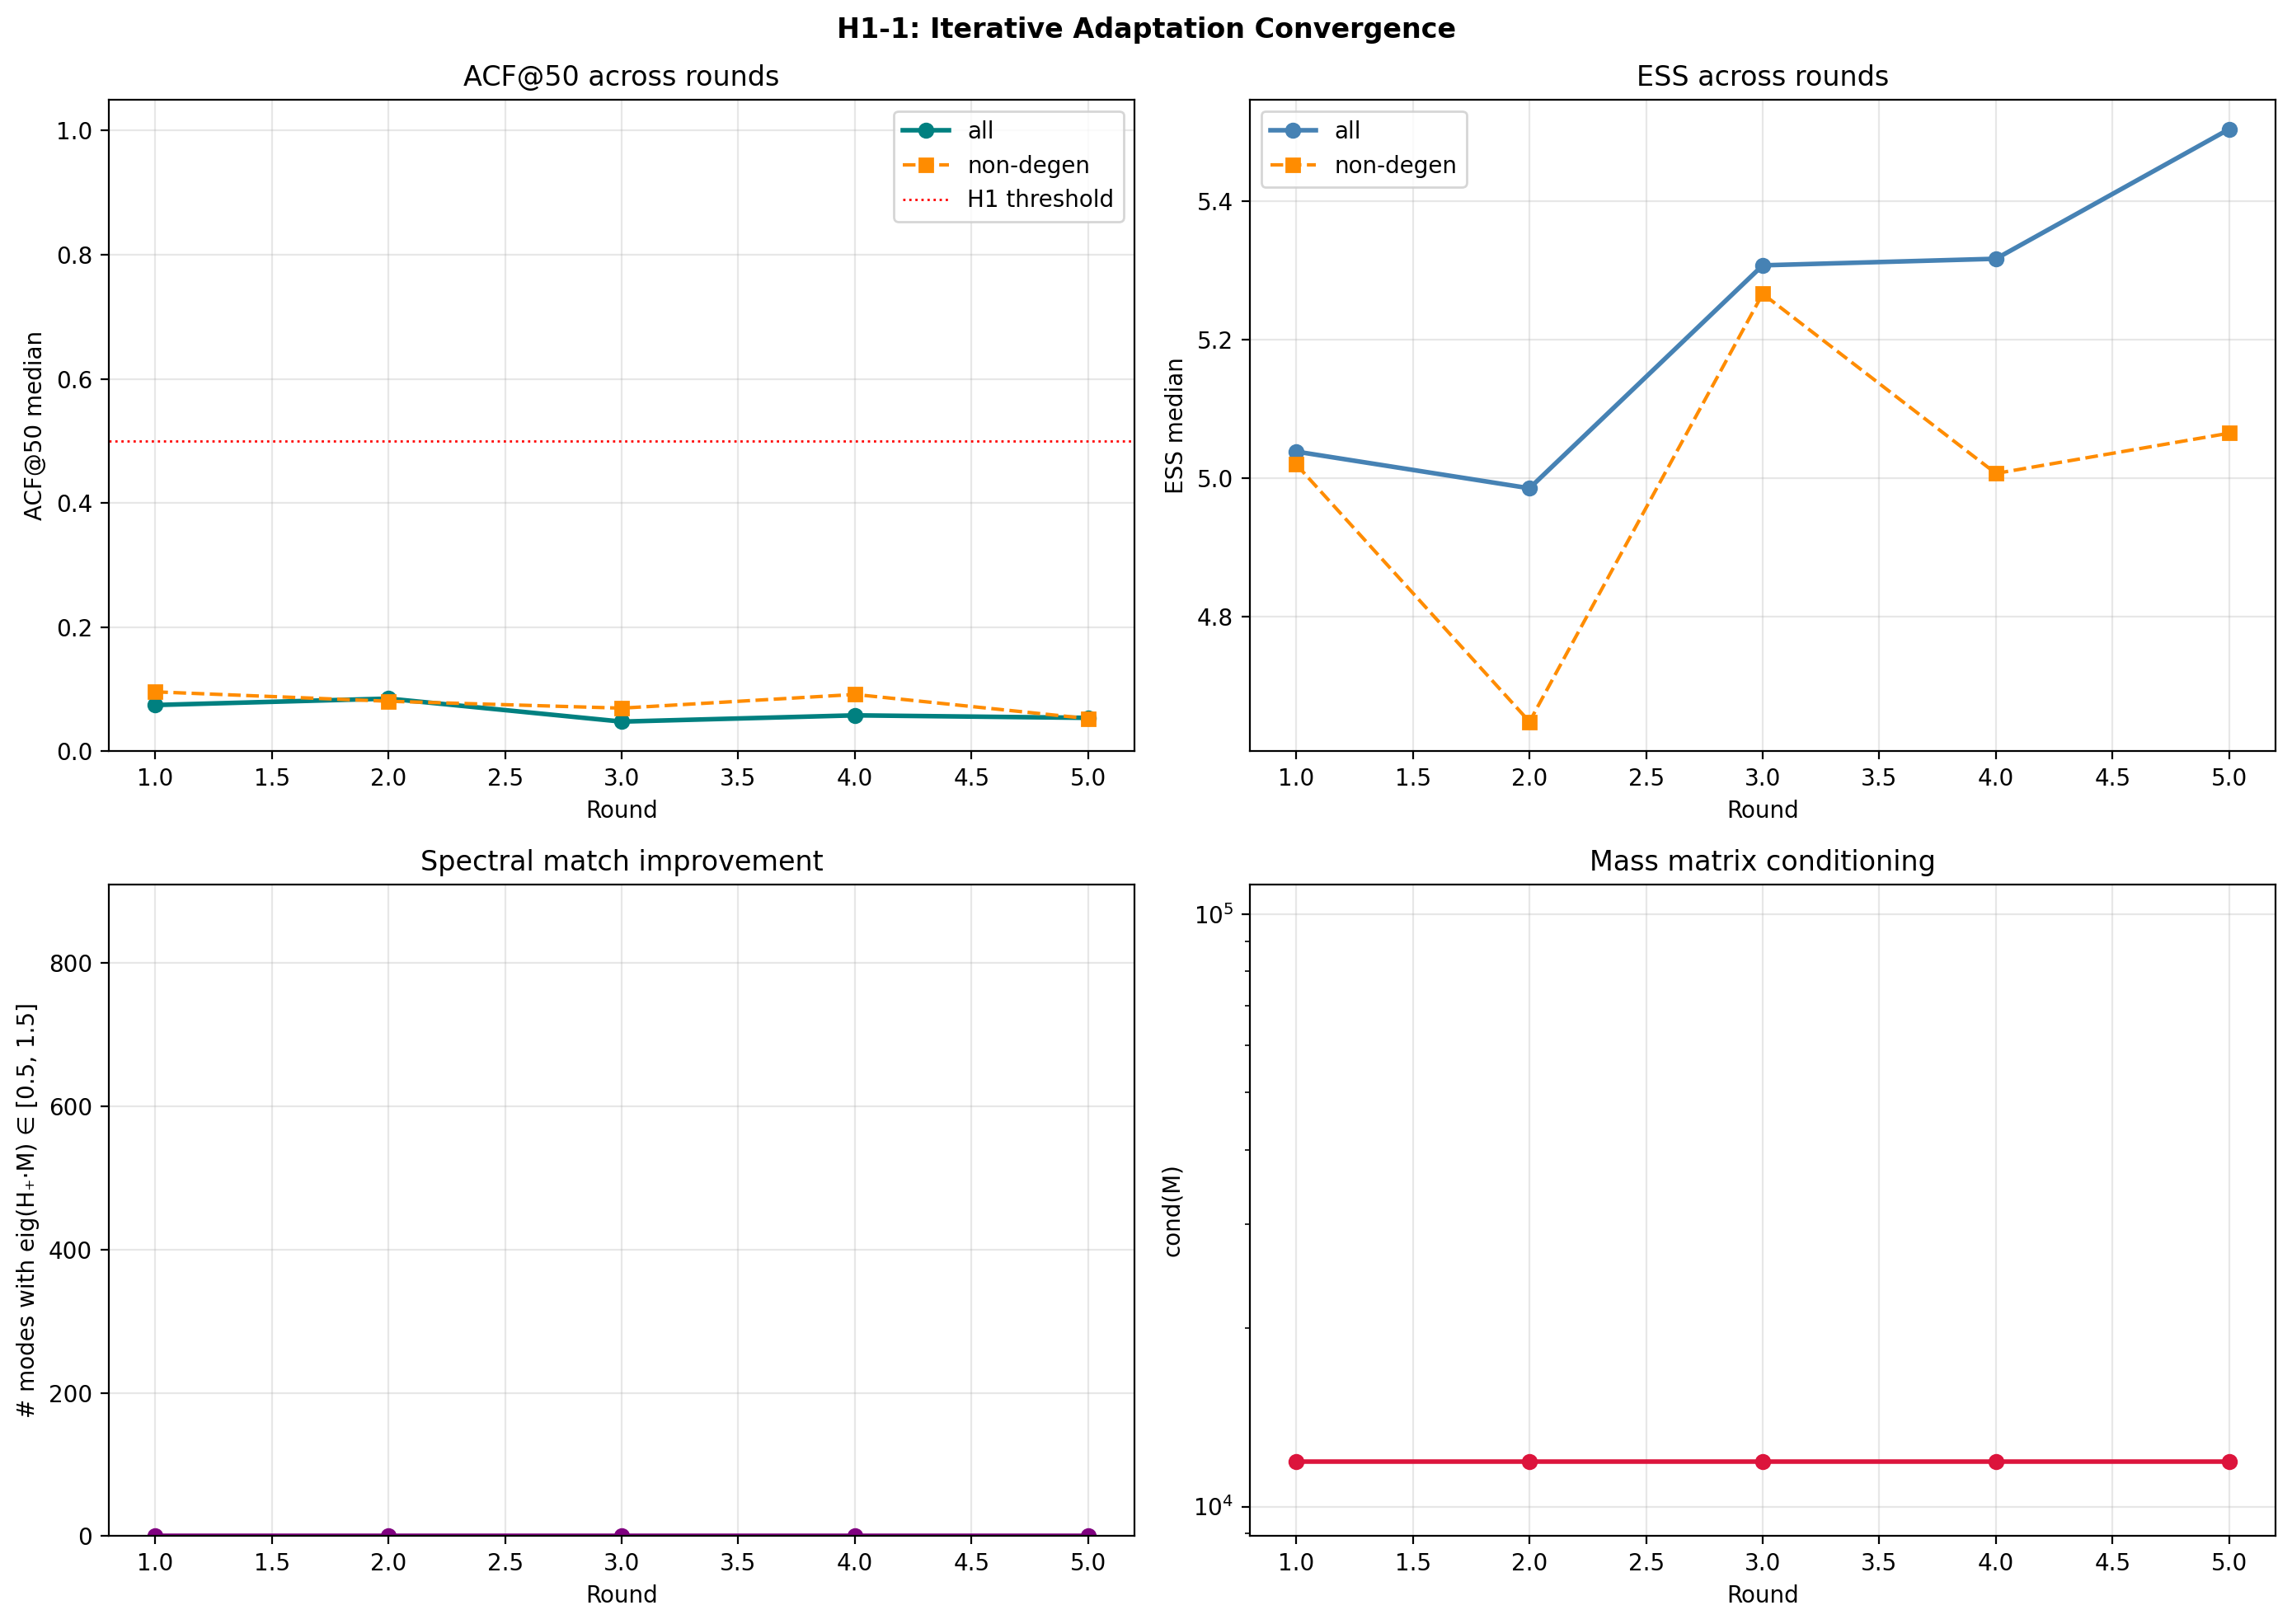


Round  ACF@50   ACF@50(nd)  ESS      ESS(nd)   #near1  cond(M)   
-----------------------------------------------------------------
1      0.075    0.096       5.0      5.0       0       1.19e+04  
2      0.085    0.081       5.0      4.6       0       1.19e+04  
3      0.048    0.070       5.3      5.3       0       1.19e+04  
4      0.058    0.092       5.3      5.0       0       1.19e+04  
5      0.054    0.053       5.5      5.1       0       1.19e+04  

★ H1-1 Final: ACF@50=0.054  ESS=5.5  gain=1.09×
  Saved: /Users/ashrafahmed/code/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/results_no_hessian/default/iterative/round_summary.json, convergence_summary.{pdf,png}


In [ ]:
if iter_results:
    rounds = [r["round"] for r in iter_results]
    acf50s = [r["acf50_median"] for r in iter_results]
    acf50_nds = [r["acf50_nd_median"] for r in iter_results]
    ess_meds = [r["ess_median"] for r in iter_results]
    ess_nd_meds = [r["ess_nd_median"] for r in iter_results]
    n_near1s = [r["n_HtM_near1"] for r in iter_results]
    conds = [r["cond_M"] for r in iter_results]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    ax.plot(rounds, acf50s, "o-", color="teal", lw=2, label="all")
    ax.plot(rounds, acf50_nds, "s--", color="darkorange", lw=1.5, label="non-degen")
    ax.axhline(0.5, color="red", ls=":", lw=1, label="H1 threshold")
    ax.set_xlabel("Round")
    ax.set_ylabel("ACF@50 median")
    ax.set_title("ACF@50 across rounds")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

    ax = axes[0, 1]
    ax.plot(rounds, ess_meds, "o-", color="steelblue", lw=2, label="all")
    ax.plot(rounds, ess_nd_meds, "s--", color="darkorange", lw=1.5, label="non-degen")
    ax.set_xlabel("Round")
    ax.set_ylabel("ESS median")
    ax.set_title("ESS across rounds")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    ax.plot(rounds, n_near1s, "o-", color="purple", lw=2)
    ax.set_xlabel("Round")
    ax.set_ylabel("# modes with eig(H₊·M) ∈ [0.5, 1.5]")
    ax.set_title("Spectral match improvement")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, d)

    ax = axes[1, 1]
    ax.plot(rounds, conds, "o-", color="crimson", lw=2)
    ax.set_xlabel("Round")
    ax.set_ylabel("cond(M)")
    ax.set_yscale("log")
    ax.set_title("Mass matrix conditioning")
    ax.grid(True, alpha=0.3)

    fig.suptitle("H1-1: Iterative Adaptation Convergence", fontweight="bold")
    fig.tight_layout()
    fig.savefig(ITER_DIR / "convergence_summary.pdf", bbox_inches="tight", dpi=150)
    fig.savefig(ITER_DIR / "convergence_summary.png", bbox_inches="tight", dpi=150)
    plt.show()

    with open(ITER_DIR / "round_summary.json", "w") as f:
        _json.dump(iter_results, f, indent=2)

    print(
        f"\n{'Round':<6} {'ACF@50':<8} {'ACF@50(nd)':<11} {'ESS':<8} {'ESS(nd)':<9} {'#near1':<7} {'cond(M)':<10}"
    )
    print("-" * 65)
    for r in iter_results:
        print(
            f"{r['round']:<6} {r['acf50_median']:<8.3f} {r['acf50_nd_median']:<11.3f} "
            f"{r['ess_median']:<8.1f} {r['ess_nd_median']:<9.1f} "
            f"{r['n_HtM_near1']:<7} {r['cond_M']:<10.2e}"
        )

    final = iter_results[-1]
    first = iter_results[0]
    gain = final["ess_median"] / max(first["ess_median"], 0.1)
    print(
        f"\n★ H1-1 Final: ACF@50={final['acf50_median']:.3f}  ESS={final['ess_median']:.1f}  gain={gain:.2f}×"
    )
    print(
        f"  Saved: {ITER_DIR / 'round_summary.json'}, convergence_summary.{{pdf,png}}"
    )
